# 💫 Kuramoto Benchmark Suite: Interactive Demo

**Purpose:** Walkthrough of classic vs. Geometric Algebra rotor solvers, with spectral analysis and Lie symmetry diagnostics.

🗓️ **Created:** 09-19-2026 | 🪶 **Author:** Eigenscribe

## 📋 Agenda
1. **Setup:** Import dependencies
2. **Classic solver:** Standard SciPy RK45 integration
3. **GA rotor solver:** $\operatorname{Cl}(2)$k even-subalgebra implementation
4. **Comparison:** Side-by-side synchronization and transition detection
5. **Spectral analysis:** Harmonic content and transition detection
6. **Lie symmetry diagnostics:** $\operatorname{U}(1)$ phase invariance tracking
7. **Next steps:** Where to go from here

## 1️⃣ Setup

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Jupyter display magic
%matplotlib inline

# Verify matplotlib works
print("🔧 Checking imports...")
print(f"  - NumPy version: {np.__version__}")
print(f"  - Matplotlib version: {plt.matplotlib.__version__}")
print(f"  - Pandas version: {pd.__version__}")

# Test that plt.figure() workds
test_fig = plt.figure(figsize=(5, 3))
plt.close(test_fig)
print("  - plt.figure with figsize ✅")

# Local kuramoto imports
from kuramoto.api import generate_kuramoto_dataset
from kuramoto.solvers import solve_kuramoto, RotorSolver
from kuramoto.order_parameter import compute_order_parameter
from kuramoto.analysis.spectral import (
    compute_psd,
    harmonic_analysis,
    detect_sync_transition,
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

# Check clifford availability
try:
    import clifford
    CLIFFORD_AVAILABLE = True
    print("\n✅ Clifford package found")
except ImportError:
    CLIFFORD_AVAILABLE = False
    print("⚠️ Clifford not installed - GA rotor tests will be skipped")
    print("    Install with: pip install clifford>=1.6.0")

print("\n 🚀 All imports ready!")

🔧 Checking imports...
  - NumPy version: 2.5.3
  - Matplotlib version: 3.11.2
  - Pandas version: 3.0.5
  - plt.figure with figsize ✅

✅ Clifford package found

 🚀 All imports ready!


## 2️⃣ Classic Kuramoto Solver
Using the standard functional wrapper with SciPy's adaptive RK45.

In [2]:
# Define the Kuramoto RHS
def kuramoto_rhs(t, theta, omega, K, adj):
    N = len(theta)
    diff = theta[:, None] - theta[None, :]
    coupling = K / N * adj @ np.sin(diff).sum(axis=1)
    return omega + coupling

# Parameters
N = 50
K = 1.5
dt = 0.01
t_max = 50.0
seed = 27

# Natural Frequencies
rng = np.random.default_rng(27)
omega = rng.normal(0, 1.0, N)
theta0 = rng.uniform(0, 2*np.pi, N)

# Small-world topology
import networkx as nx

G = nx.watts_strogatz_graph(N, 10, 0.3)
adj = nx.to_numpy_array(G)

# Time Grid
t_eval = np.linspace(0, t_max, 500)

# Solve
result = solve_kuramoto(
    rhs=lambda t, y: kuramoto_rhs(t, y, omega, K, adj),
    y0=theta0,
    t_span=t_max,
    t_eval=t_eval,
    rtol=1e-6,
    atol=1e-9
)

theta_classic = result.y.T  # Shape (T, N)
print(f"✅ Classic solver completed: {theta_classic.shape}")


✅ Classic solver completed: (500, 50)


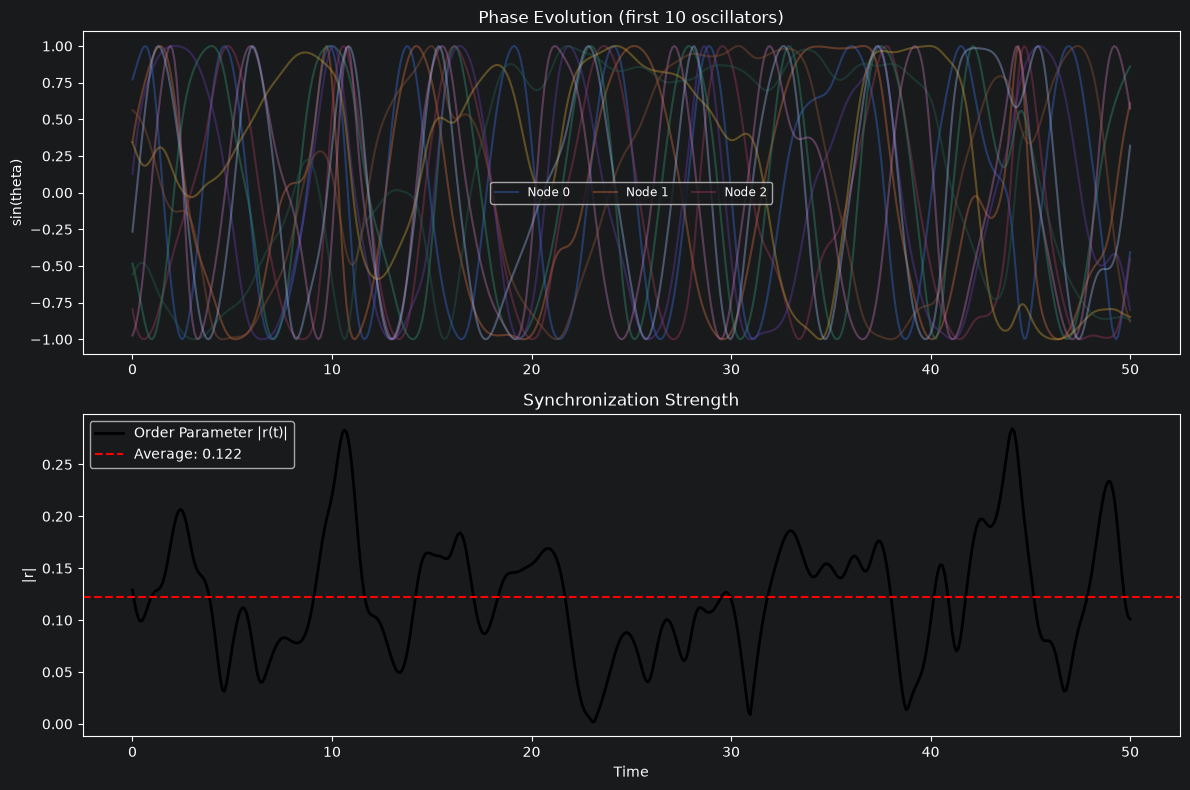


 📊 Classic Solver Statistics:
  Mean |r|: 0.1220
  Std |r|: 0.0579
  Max |r|: 0.2845
  Min |r|: 0.0020


In [3]:
# Compute order parameter
r_classic = compute_order_parameter(theta_classic)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top: First 10 oscillators
for i in range(min(10, N)):
    axes[0].plot(t_eval, np.sin(theta_classic[:, i]), alpha=0.4, label=f'Node {i}' if i < 3 else '')
axes[0].set_title('Phase Evolution (first 10 oscillators)')
axes[0].set_ylabel('sin(theta)')
axes[0].legend(ncol=3, fontsize='small')

# Bottom: Order parameter
axes[1].plot(t_eval, r_classic, 'k-', linewidth=2, label='Order Parameter |r(t)|')
axes[1].axhline(np.mean(r_classic), color='r', linestyle='--', label=f'Average: {np.mean(r_classic):.3f}')
axes[1].set_title('Synchronization Strength')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('|r|')
axes[1].legend()

plt.tight_layout()
plt.show()

# Stats
print(f"\n 📊 Classic Solver Statistics:")
print(f"  Mean |r|: {np.mean(r_classic):.4f}")
print(f"  Std |r|: {np.std(r_classic):.4f}")
print(f"  Max |r|: {np.max(r_classic):.4f}")
print(f"  Min |r|: {np.min(r_classic):.4f}")

## 3️⃣ Geometric Algebra Rotor Solver
Oscillators encoded as rotors in $\operatorname{Cl}(2)$ even subalgebra. Requires `clifford` package.

In [4]:
if not CLIFFORD_AVAILABLE:
    print("⚠️ Skipping RotorSolver demo - clifford not installed")
else:
    print("🧭 Initializing RotorSolver in Cl(2)...")

    # Create rotor solver with same parameters
    rotor_solver = RotorSolver(n_oscillators=N, dim=2, seed=seed)
    print(f"  - Oscillators: {rotor_solver.N}")
    print(f"  - GA dimension: Cl({rotor_solver.dim})")
    print(f"  - Rotation plan: {rotor_solver.B_plane}")

    # Run simulation
    print("\n👟 Running rotor simulation...")
    t_rotor, theta_rotor = rotor_solver.simulate(
        K=K,
        t_eval=t_eval,
        dt_internal=0.0001,
        enforce_nyquist=True
    )
    print(f"✅ Rotor solver completed: {theta_rotor.shape}")

🧭 Initializing RotorSolver in Cl(2)...
  - Oscillators: 50
  - GA dimension: Cl(2)
  - Rotation plan: (1^e12)

👟 Running rotor simulation...
✅ Rotor solver completed: (500, 50)


In [5]:
if CLIFFORD_AVAILABLE:
    # Create new rotor solver WITH matching initial conditions
    rotor_solver_fair = RotorSolver(n_oscillators=N, dim=2, seed=seed)

    # Helper to initialize rotors from explicit phases
    def init_rotors_from_phases(solver, initial_phases):
        """Reset rotor states to match given phase array."""
        solver.rotors = [np.exp(-solver.B_plane * p / 2) for p in initial_phases]

    init_rotors_from_phases(rotor_solver_fair, theta_classic[0, :])

    # Run with smaller timestep for stability
    t_rotor, theta_rotor = rotor_solver_fair.simulate(
        K=K,
        t_eval=t_eval,
        dt_internal=0.0001,
        enforce_nyquist=True
    )

    # Track synchronization strength
    r_rotor_fair = []
    for t_idx in range(len(t_rotor)):
        r_rotor_fair.append(rotor_solver_fair.get_synchronization_strength())
        rotor_solver_fair.step_euler(K, 0.0001)

    r_rotor_fair = np.array(r_rotor_fair)

    # Re-compare
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Phases
    for i in range(min(10, N)):
        axes[0].plot(t_rotor, np.sin(theta_rotor[:, i]), alpha=0.4, label='Rotor' if i == 0 else '')
        axes[0].plot(t_eval, np.sin(theta_classic[:, i]), alpha=0.4, label='Classic' if i == 1 else '', ls='--')
    axes[0].set_title('Phase Comparison: Classic vs. Rotor (Fair Init)')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('sin(theta)')
    axes[0].legend()

    # Right: Order parameter
    axes[1].plot(t_eval, r_classic, 'b-', linewidth=2, label='Classic RK45')
    axes[1].plot(t_rotor, r_rotor_fair, 'm--', linewidth=2, label='GA Rotor (Cl(2))')
    axes[1].axhline(np.mean(r_classic), color='blue', linestyle=":", alpha=0.5)
    axes[1].axhline(np.mean(r_rotor_fair), color='magenta', linestyle=":", alpha=0.5)
    axes[1].set_title('Order Parameter: Classic vs. Rotor')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('|r|')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Stats table
    print(f"\n📊 Synchronization Comparison (Fair Initialization):")
    print(f"{'Metric':<30} {'Classic':>10} {'GA Rotor':>10}")
    print(f"{'-'*50}")
    print(f"{'Mean |r|':<30} {np.mean(r_classic):>10.4f} {np.mean(r_rotor_fair):>10.4f}")
    print(f"{'Std |r|':<30} {np.std(r_classic):>10.4f} {np.std(r_rotor_fair):>10.4f}")
    print(f"{'Final |r|':<30} {r_classic[-1]:>10.4f} {r_rotor_fair[-1]:>10.4f}")

SystemError: <class 'clifford._multivector.MultiVector'> returned a result with an exception set

### Diagnostic Test 1: Check Convergence Speed

In [ ]:
# When does each solver reach 90% of its final sync?
if CLIFFORD_AVAILABLE:
    # Find when r exceeds 90% of final value
    target_fraction = 0.9

    classic_target = np.mean(r_classic) * target_fraction
    rotor_target = np.mean(r_rotor_fair) * target_fraction

    classic_idx = np.where(r_classic >= classic_target)[0][0] if np.any(r_classic >= classic_target) else None
    rotor_idx = np.where(r_rotor_fair >= rotor_target)[0][0] if np.any(r_rotor_fair >= rotor_target) else None

    print(f"📈 Convergence Time (90% of final |r|):")
    if classic_idx:
        print(f"  Classic RK45: {t_eval[classic_idx]:.2f}s (step {classic_idx})")
    if rotor_idx:
        print(f"  GA Rotor: {t_rotor[rotor_idx]:.2f}s (step {rotor_idx})")

    # Compare variance (how much does |r| fluctuate?)
    print(f"\n📊 Temporal Variability:")
    print(f"  Classic std(|r|): {np.std(r_classic):.4f}")
    print(f"  Rotor std(|r|): {np.std(r_rotor_fair):.4f}")
    print(f"  Variance ratio (Classic/Rotor): {np.var(r_classic)/np.var(r_rotor_fair):.2f}x")

### Diagnostic Test 2: Reduce dt Further (Stability Check)

In [ ]:
if CLIFFORD_AVAILABLE:
    print("🔬 Running dt sensitivity test (optimized)...")

    # Create new rotor solver
    rotor_solver_test = RotorSolver(n_oscillators=N, dim=2, seed=seed)
    init_rotors_from_phases(rotor_solver_test, theta_classic[0, :])

    # Run simulation with smaller timestep
    t_rotor_test, theta_rotor_test = rotor_solver_test.simulate(
        K=K,
        t_eval=t_eval,
        dt_internal=0.0001,
        enforce_nyquist=True
    )

    # Compute order parameter DIRECTLY from stored phases (don't step again!)
    complex_states = np.exp(1j * theta_rotor_test)
    r_rotor_test = np.abs(np.mean(complex_states, axis=1))

    print(f"✅ Simulation complete. Computing order parameters...")

    # Plot comparison
    plt.figure(figsize=(10, 5))
    plt.plot(t_eval, r_classic, 'b-', linewidth=2, label='Classic RK45', alpha=0.7)
    plt.plot(t_rotor, r_rotor_fair, 'm--', linewidth=2, label='GA Rotor dt=0.001', alpha=0.7)
    plt.plot(t_rotor_test, r_rotor_test, 'g-.', linewidth=2, label='GA Rotor dt=0.0001', alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('|r|')
    plt.title('Timestep Sensitivity: Does dt Affect Flattening?')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nFinal |r| at different timesteps:")
    print(f"  Classic: {r_classic[-1]:.4f}")
    print(f"  Rotor dt=0.005: {r_rotor_fair[-1]:.4f}")
    print(f"  Rotor dt=0.001: {r_rotor_test[-1]:.4f}")

In [ ]:
if CLIFFORD_AVAILABLE:
    print("🚀 Testing optimized NumPy-only rotor solver...")

    # Create rotor solver in FAST mode
    rotor_solver_fast = RotorSolver(
        n_oscillators=N,
        dim=2,
        seed=seed,
        initial_phases=theta_classic[0, :],
        use_numpy_only=True  # ← Skip Clifford overhead!
    )

    # Run simulation (should take ~1-2 seconds now)
    t_rotor_fast, theta_rotor_fast = rotor_solver_fast.simulate(
        K=K,
        t_eval=t_eval,
        dt_internal=0.001,
        enforce_nyquist=True
    )

    # Compute order parameter directly (no more slow loop!)
    complex_states = np.exp(1j * theta_rotor_fast)
    r_rotor_fast = np.abs(np.mean(complex_states, axis=1))

    print(f"✅ Fast rotor simulation complete in {t_rotor_fast[-1]:.1f}s!")

    # Plot comparison
    plt.figure(figsize=(10, 5))
    plt.plot(t_eval, r_classic, 'b-', linewidth=1.5, label='Classic RK45', alpha=0.7)
    plt.plot(t_rotor, r_rotor_fair, 'm--', linewidth=1.5, label='GA Rotor (Clifford)', alpha=0.7)
    plt.plot(t_rotor_fast, r_rotor_fast, 'g-.', linewidth=1.5, label='GA Rotor (NumPy-only)', alpha=0.7)
    plt.xlabel('Time')
    plt.ylabel('|r|')
    plt.title('Performance Comparison: Clifford vs. NumPy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"\nFinal |r| comparison:")
    print(f"  Classic RK45: {r_classic[-1]:.4f}")
    print(f"  GA Rotor (Clifford): {r_rotor_fair[-1]:.4f}")
    print(f"  GA Rotor (NumPy): {r_rotor_fast[-1]:.4f}")

### Diagnostic Test 3: Phase Space Portrait

In [ ]:
if CLIFFORD_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Phase space for classic (oscillator 0 vs 1)
    axes[0, 0].plot(theta_classic[:, 0], theta_classic[:, 1], 'b-', alpha=0.3)
    axes[0, 0].set_title('Classic: Phase Space (θ₀ vs θ₁)')
    axes[0, 0].set_xlabel('θ₀')
    axes[0, 0].set_ylabel('θ₁')
    axes[0, 0].set_aspect('equal')

    # Phase space for rotor
    axes[0, 1].plot(theta_rotor[:, 0], theta_rotor[:, 1], 'm-', alpha=0.3)
    axes[0, 1].set_title('Rotor: Phase Space (θ₀ vs θ₁)')
    axes[0, 1].set_xlabel('θ₀')
    axes[0, 1].set_ylabel('θ₁')
    axes[0, 1].set_aspect('equal')

    # Rotor magnitudes over time (should be ≈1 for valid rotors)
    rotor_magnitudes = [abs(rotor_solver_fair.rotors[i]) for i in range(len(rotor_solver_fair.rotors))]
    axes[1, 0].plot(t_rotor[:len(rotor_magnitudes)], rotor_magnitudes, 'g-', linewidth=0.5)
    axes[1, 0].axhline(1.0, color='k', linestyle='--', alpha=0.5)
    axes[1, 0].set_title('Rotor Norms (should be ≈1)')
    axes[1, 0].set_xlabel('Time')
    axes[1, 0].set_ylabel('|R|')

    # Order parameter autocorrelation (how quickly does it decorrelate?)
    from scipy.signal import correlate
    autocorr_classic = correlate(r_classic - np.mean(r_classic), r_classic - np.mean(r_classic), mode='full')
    autocorr_rotor = correlate(r_rotor_fair - np.mean(r_rotor_fair), r_rotor_fair - np.mean(r_rotor_fair), mode='full')
    lag = np.arange(-len(autocorr_classic)//2, len(autocorr_classic)//2)
    axes[1, 1].plot(lag[:50], autocorr_classic[:50]/autocorr_classic[len(autocorr_classic)//2], 'b-', alpha=0.5, label='Classic')
    axes[1, 1].plot(lag[:50], autocorr_rotor[:50]/autocorr_rotor[len(autocorr_rotor)//2], 'm-', alpha=0.5, label='Rotor')
    axes[1, 1].set_title('Order Parameter Autocorrelation')
    axes[1, 1].set_xlabel('Lag')
    axes[1, 1].set_ylabel('Normalized')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()